In [1]:
import numpy as np
import matplotlib.pyplot as plt

from phase import aia, remove_carrier, subtract_reference

REPO_ROOT = "/Users/rodionsa/Library/CloudStorage/GoogleDrive-sergeyrodionov93@gmail.com/My Drive/work/Projects/HoloEML/holoeml-processing"
DATA_DIR = REPO_ROOT + "/data/"

delta_crop = 400

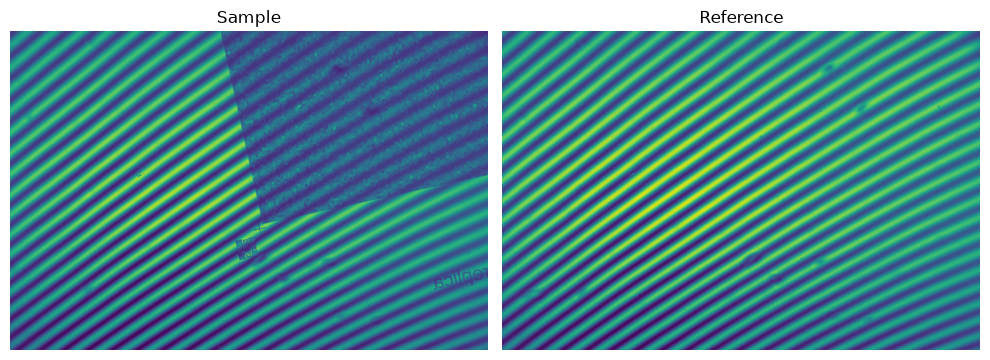

In [45]:
# Read data
data = np.load(DATA_DIR + "piezo_scan_meta_20260721_180448.npz")
images = data['images'][:, delta_crop:3000-delta_crop, delta_crop:4096-delta_crop,0]

data_ref = np.load(DATA_DIR + "piezo_scan_meta_ref_20260721_180721.npz")
images_ref = data_ref['images'][:, delta_crop:3000-delta_crop, delta_crop:4096-delta_crop,0]

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.title("Sample")
plt.imshow(images[0])
plt.axis('off')

plt.subplot(122)
plt.title("Reference")
plt.imshow(images_ref[0])
plt.axis('off')

plt.tight_layout()

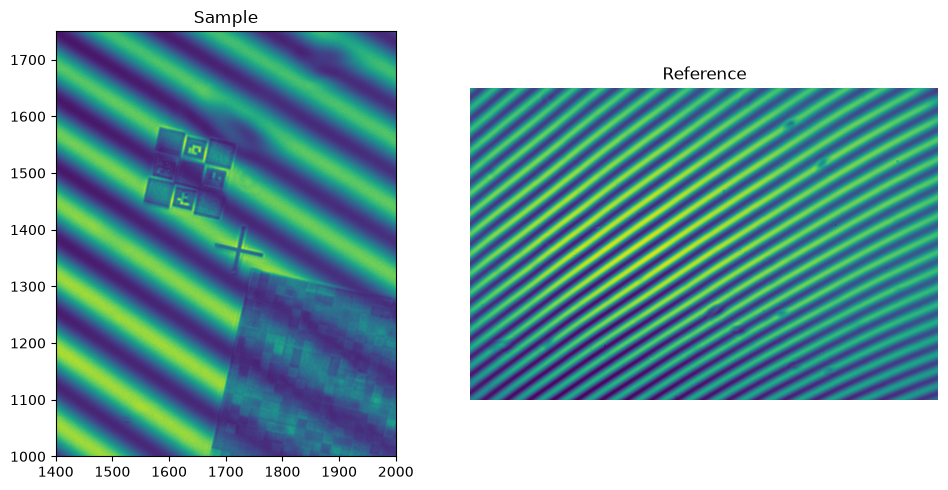

In [49]:
plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.title("Sample")
plt.imshow(images[0])
plt.xlim([1400, 2000])
plt.ylim([1000, 1750])

plt.subplot(122)
plt.title("Reference")
plt.imshow(images_ref[0])
plt.axis('off')

plt.tight_layout()

In [25]:
# Extract phases
# gain="auto" measures each frame's fringe contrast from its spatial carrier and
# holds it fixed in the AIA solve, instead of assuming every frame has the same
# contrast. On this setup the true per-frame contrast swings ~50-70% across a
# scan; forcing one shared contrast otherwise leaks a phase-locked error into
# phi (biggest at the fundamental) that survives subtract_reference because the
# sample and reference scans have different contrast sequences.
results = aia(images, gain="auto")
results_ref = aia(images_ref, gain="auto")

a = results.a
b = results.b
phi = results.phi
delta = results.delta
g = results.g

a_ref = results_ref.a
b_ref = results_ref.b
phi_ref = results_ref.phi
delta_ref = results_ref.delta
g_ref = results_ref.g

print(f"Converged: {results.converged}")
print(f"Converged_ref: {results_ref.converged}")
print(f"Kappa_p: {results.kappa_p}")
print(f"Kappa_p_ref: {results_ref.kappa_p}")
print(f"Kappa_ps: {results.kappa_ps}")
print(f"Kappa_ps_ref: {results_ref.kappa_ps}")
print(f"Predicted RMS: {results.predicted_rms}")
print(f"Predicted_ref RMS: {results_ref.predicted_rms}")
print(f"Per-frame contrast g range: {g.min():.2f}-{g.max():.2f}")
print(f"Per-frame contrast g_ref range: {g_ref.min():.2f}-{g_ref.max():.2f}")

Converged: True
Converged_ref: True
Kappa_p: 2.332675725727546
Kappa_p_ref: 2.775468681663424
Kappa_ps: 2.0061324224708748
Kappa_ps_ref: 2.0028882162109225
Predicted RMS: 0.02197360555219848
Predicted_ref RMS: 0.026977534850635074
Per-frame contrast g range: 0.71-1.38
Per-frame contrast g_ref range: 0.76-1.43


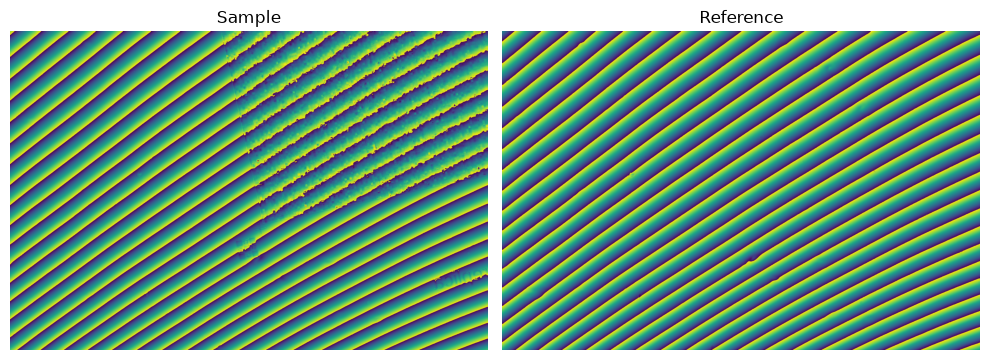

In [26]:
# Plot phi
plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.title("Sample")
plt.imshow(phi)
plt.axis('off')

plt.subplot(122)
plt.title("Reference")
plt.imshow(phi_ref)
plt.axis('off')

plt.tight_layout()

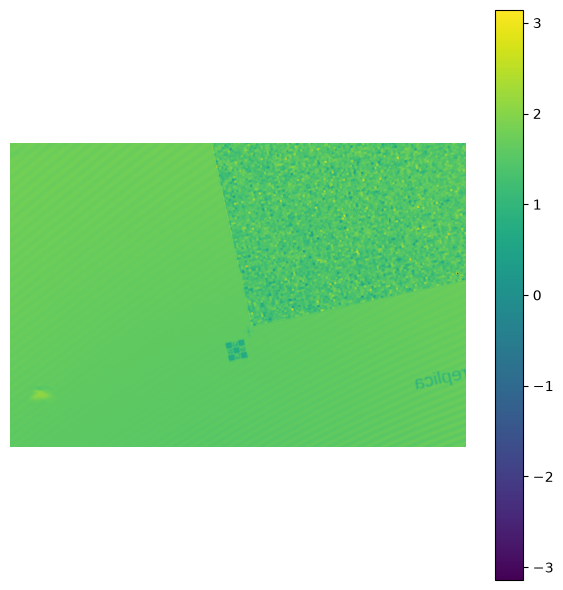

In [27]:
# Phase difference
diff_res =  subtract_reference(phi, phi_ref, b)
phi_diff = diff_res.phi

plt.figure(figsize=(6, 6))
plt.imshow(phi_diff)
plt.axis('off')
plt.colorbar()

plt.tight_layout()

In [28]:
# Remove phase carrier
# weight=b restores down-weighting of low-modulation pixels; defocus=True also
# removes quadratic curvature, not just the linear tilt -- both were dropped in
# this cell relative to the original design and should stay on.
carrier_results = remove_carrier(phi_diff, defocus=True, refine_iters=10, n_blocks=10)
phi_clean = carrier_results.phi

print(f"kx/2pi: {carrier_results.fx}")
print(f"ky/2pi: {carrier_results.fy}")
print(f"kxx: {carrier_results.kxx}")
print(f"kyy: {carrier_results.kyy}")
print(f"kxy: {carrier_results.kxy}")
print(f"piston: {carrier_results.piston}")

kx/2pi: -3.8070383790765654e-05
ky/2pi: -1.7229994680563583e-05
kxx: 4.8457768900254676e-08
kyy: 8.709886559272798e-10
kxy: 6.168756695495318e-08
piston: 1.7991985665409727


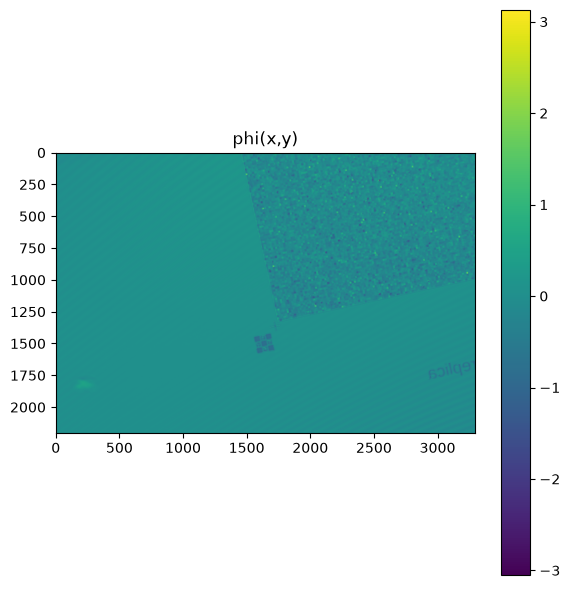

In [29]:
# Plot phi_clean
plt.figure(figsize=(6, 6))

plt.title("phi(x,y)")
plt.imshow(phi_clean)
# plt.xlim([1000, 2000])
# plt.ylim([1100, 1900])
plt.colorbar()

plt.tight_layout()

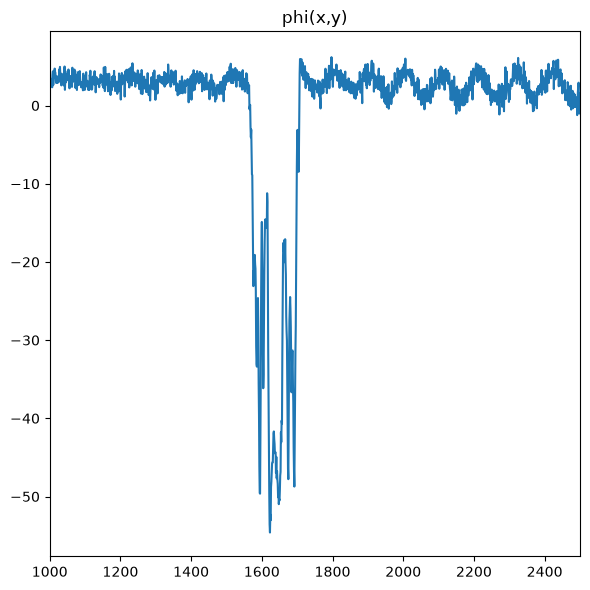

In [30]:
# Plot phi_clean
plt.figure(figsize=(6, 6))

plt.title("phi(x,y)")
plt.plot(phi_clean[1500,:]/np.pi*180)
plt.xlim([1000, 2500])
# plt.ylim([-30, 30])
plt.tight_layout()

## Residual ripple: findings (updated)

Diagnosed on a glass-vs-glass null test (independent bare-glass scans, true
difference = 0), on real acquisition data:

- **Baseline** (`aia()` with no `gain`): ripple std 2.68°, p99 5.63°.
- **`gain="auto"` (this notebook uses it)**: per-frame fringe contrast swings
  ~50-70% across a scan; forcing one shared contrast leaked a phase-locked
  error into `phi`. Measuring it independently and holding it fixed roughly
  halves the ripple: std ~1.3-1.5°, p99 ~4-4.2°.
- ~~Reference-mirror tilt during the piezo step~~ **retracted.** An earlier
  pass measured this at "up to 110° edge-to-edge" using an FFT-peak
  centroid and a raw amplitude-weighted gradient on the Takeda-demodulated
  field; both are unreliable there because that field spans ~13 orders of
  magnitude in amplitude and the estimate is dominated by a handful of
  near-zero pixels. Measured properly (coherently averaging the
  frame-to-frame field over a coarse patch grid, then plane-fitting the
  patch phases), the real tilt is **~5-8° peak-to-peak** -- and fitting it
  (per-pixel AIA with the measured ramp `delta_n(x,y) = d_n + p_n*x + q_n*y`
  held fixed) changed the null-test residual by **0.002°**. Not worth
  chasing, in software or in hardware.
- **What the residual actually is:** decomposing 5 repeat bare-glass scans
  into a common part and per-scan scatter -- each single acquisition has
  ~5.7° of residual structure, of which **~5.5° is common to all 5**
  (almost certainly the real, repeatable surface figure of the glass, ~λ/65
  -- ordinary, and it cancels in any difference), leaving **~1.15°/scan of
  genuine random scatter** (vibration, air currents, source noise -- not a
  per-frame model error, so `gain`/tilt-style fixes don't touch it).

**This is why averaging repeats works and fitting the tilt doesn't:** the
1.15°/scan component is independent between scans and averages down as
`1/sqrt(k)` -- verified directly: difference of two disjoint averages of
bare-glass scans measures **1.81° for k=1** and **1.30° for k=2**, matching
the ideal `1/sqrt(2) = 1.28` prediction. `phase.combine.combine_acquisitions`
(below) does this: resolves each scan's `+/-phi` sign branch, removes each
one's own carrier/piston/defocus drift, then takes the complex mean --
returning both the combined `phi` and a per-pixel `scatter` map (the
empirical uncertainty). `aia`'s own `predicted_rms` for these scans is
~0.04 rad (~2.3°), so at 1.15°/scan the algorithm is already at its noise
floor; more repeats, not more modeling, is the lever from here.


In [4]:
# Combine repeated acquisitions to reduce the random ~1.15deg/scan floor.
# Processes one stack at a time (only phi/b are kept) so this doesn't need all
# five 30x2200x3296 stacks in memory simultaneously. This cell is slow (10 aia
# calls at full ROI size) -- run it once the single-pair check above looks right.
from phase import combine_acquisitions

sample_files = [
    "piezo_scan_meta_20260721_180448.npz",
    "piezo_scan_meta_20260721_180510.npz",
    "piezo_scan_meta_20260721_180532.npz",
    "piezo_scan_meta_20260721_180556.npz",
    "piezo_scan_meta_20260721_180617.npz",
]
ref_files = [
    "piezo_scan_meta_ref_20260721_180721.npz",
    "piezo_scan_meta_ref_20260721_180742.npz",
    "piezo_scan_meta_ref_20260721_180804.npz",
    "piezo_scan_meta_ref_20260721_180831.npz",
    "piezo_scan_meta_ref_20260721_180853.npz",
]

def phase_and_modulation(fname):
    d = np.load(DATA_DIR + fname)
    stack = d['images'][:, delta_crop:3000-delta_crop, delta_crop:4096-delta_crop, 0]
    r = aia(stack, gain="auto")
    return r.phi, r.b

sample_phis, sample_bs = zip(*(phase_and_modulation(f) for f in sample_files[:]))
ref_phis, ref_bs = zip(*(phase_and_modulation(f) for f in ref_files[:]))

sample_combined = combine_acquisitions(list(sample_phis), list(sample_bs))
ref_combined = combine_acquisitions(list(ref_phis), list(ref_bs))

print(f"sample: n={sample_combined.n}, sign_flips={sample_combined.sign_flips}, "
      f"median scatter={np.degrees(np.median(sample_combined.scatter)):.3f} deg")
print(f"ref:    n={ref_combined.n}, sign_flips={ref_combined.sign_flips}, "
      f"median scatter={np.degrees(np.median(ref_combined.scatter)):.3f} deg")

sample: n=5, sign_flips=[1], median scatter=1.209 deg
ref:    n=5, sign_flips=[1], median scatter=1.156 deg


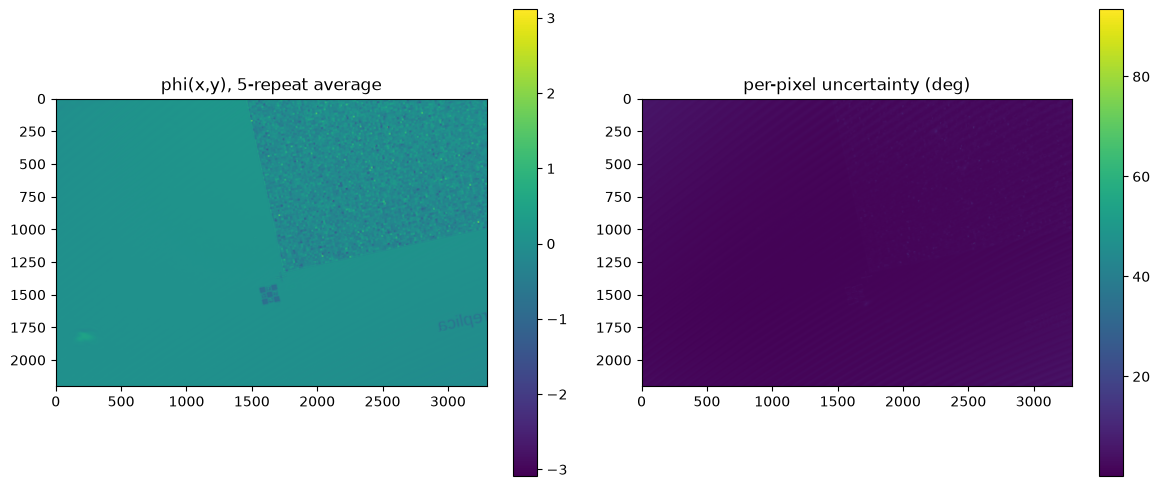

In [5]:
# Final difference from the combined (5-repeat-averaged) maps, and its
# per-pixel uncertainty (combining both scans' scatter in quadrature).
diff_combined = subtract_reference(sample_combined.phi, ref_combined.phi, sample_combined.mean_resultant)
carrier_combined = remove_carrier(diff_combined.phi, sample_combined.mean_resultant,
                                   defocus=True, refine_iters=10, n_blocks=10)
phi_clean_combined = carrier_combined.phi
uncertainty_combined = np.hypot(sample_combined.scatter, ref_combined.scatter)

plt.figure(figsize=(12, 5))
plt.subplot(121)
plt.title("phi(x,y), 5-repeat average")
plt.imshow(phi_clean_combined)
plt.colorbar()
plt.subplot(122)
plt.title("per-pixel uncertainty (deg)")
plt.imshow(np.degrees(uncertainty_combined))
plt.colorbar()
plt.tight_layout()

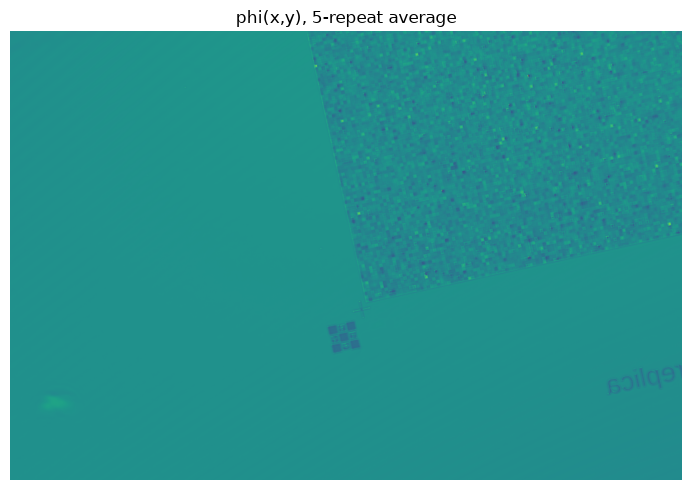

In [44]:
plt.figure(figsize=(12, 5))
plt.title("phi(x,y), 5-repeat average")
plt.imshow(phi_clean_combined)
#plt.colorbar()
# plt.xlim([1600, 2100])
# plt.ylim([1000, 1400])
plt.axis('off')
plt.tight_layout()

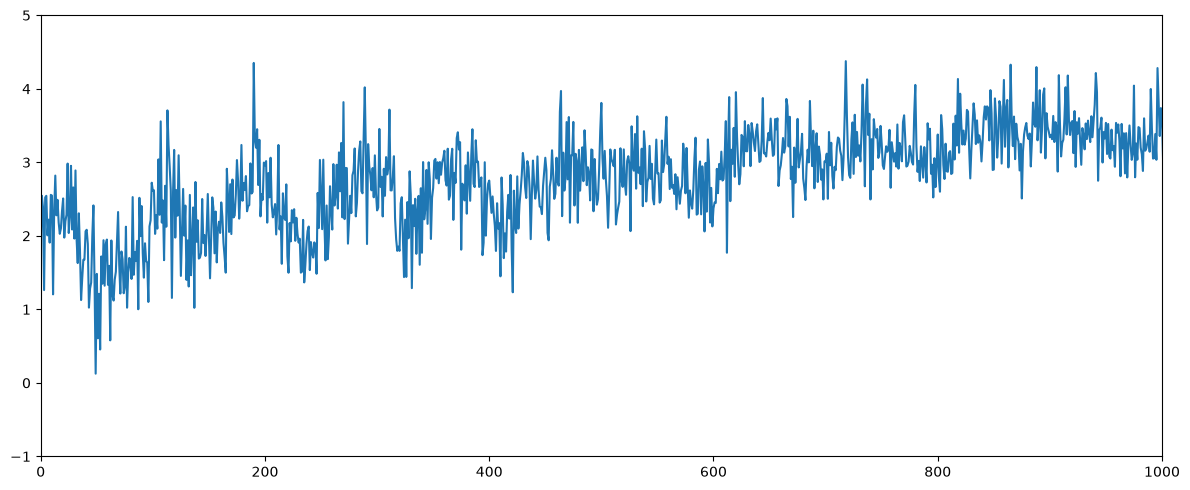

In [25]:
plt.figure(figsize=(12, 5))
plt.plot(phi_clean_combined[1500]*180/np.pi)
#plt.xlim([1300, 1900])
plt.xlim([0, 1000])
plt.ylim([-1, 5])
plt.tight_layout()

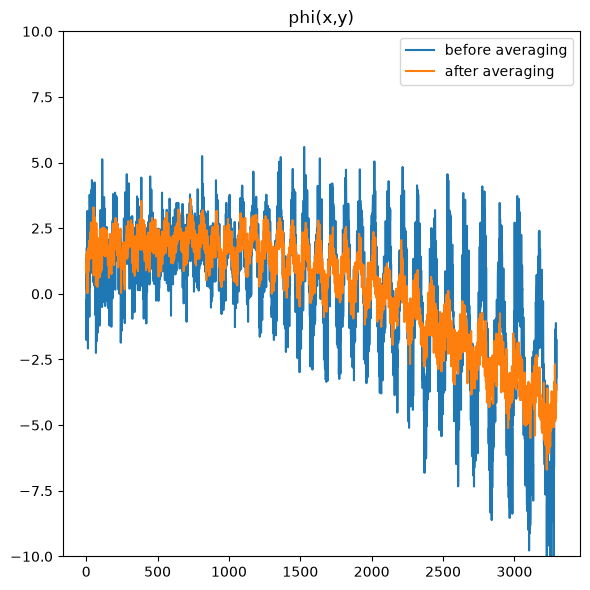

In [42]:
# Plot phi_clean
plt.figure(figsize=(6, 6))

plt.title("phi(x,y)")
plt.plot(phi_clean[2000,:]/np.pi*180, label="before averaging")
plt.plot(phi_clean_combined[2000]*180/np.pi, label="after averaging")
#plt.xlim([2000, 2600])
#plt.xlim([1000, 2500])
plt.ylim([-10, 10])
plt.legend()
plt.tight_layout()

## Error vs. number of averages, and error vs. number of AIA points

Two follow-up sweeps on the same sample/ref scans used above.

- **Test A** -- fixed 30 AIA frames per scan, vary the number of averaged
  repeat scans `k` from 2 to 5 (all 5 sample/ref files are available). Error
  metric is `std(phi_clean_combined)`, the std of the final combined
  difference map (same map plotted as "5-repeat average" above), computed by
  running `subtract_reference` + `remove_carrier` on the k-averaged sample/ref
  maps for each `k`. Slow: runs `aia` once per file (10 calls at full ROI
  size) and reuses those `phi`/`b` maps for every `k` via
  `combine_acquisitions`, so the sweep itself is cheap once that's done.
- **Test B** -- fixed number of averaged repeats `K_FIXED` (edit this to
  taste), vary the number of AIA phase-shift frames per scan from 5 to 30 in
  steps of 5. Loads the raw stacks for the first `K_FIXED` sample/ref files
  once, then reruns `aia` on a growing frame-count slice each iteration --
  `len(n_points_list) * 2 * K_FIXED` total `aia` calls, so reduce `K_FIXED`
  if this is too slow.

k=2: std(phi_clean_combined)=1.428 deg
k=3: std(phi_clean_combined)=1.512 deg
k=4: std(phi_clean_combined)=1.175 deg
k=5: std(phi_clean_combined)=0.911 deg


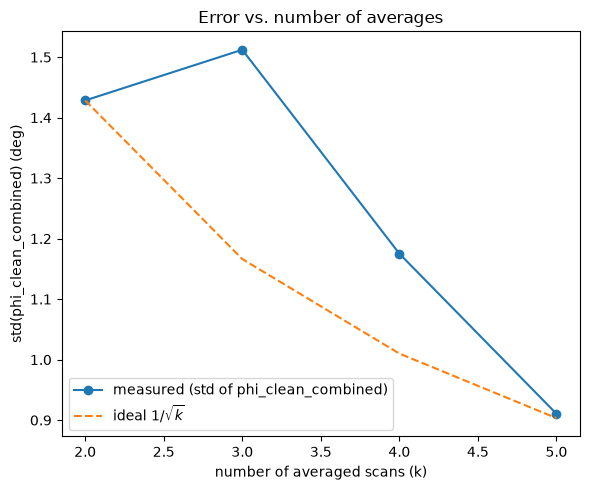

In [61]:
# Test A: error vs. number of averaged repeats (k = 2..5), 30 AIA frames each.
# Error metric: std of the final combined difference map phi_clean_combined
# (same map as the "5-repeat average" plot above -- subtract_reference then
# remove_carrier on the k-averaged sample/ref maps).
sample_phis_full, sample_bs_full = zip(*(phase_and_modulation(f) for f in sample_files))
ref_phis_full, ref_bs_full = zip(*(phase_and_modulation(f) for f in ref_files))

k_values = list(range(2, len(sample_files) + 1))
errors_vs_k = []

for k in k_values:
    sample_c = combine_acquisitions(list(sample_phis_full[:k]), list(sample_bs_full[:k]))
    ref_c = combine_acquisitions(list(ref_phis_full[:k]), list(ref_bs_full[:k]))

    diff_c = subtract_reference(sample_c.phi, ref_c.phi, sample_c.mean_resultant)
    carrier_c = remove_carrier(diff_c.phi, sample_c.mean_resultant,
                                defocus=True, refine_iters=10, n_blocks=10)
    phi_clean_c = carrier_c.phi

    err_deg = np.degrees(np.std(phi_clean_c[400:600, 500:700]))
    errors_vs_k.append(err_deg)
    print(f"k={k}: std(phi_clean_combined)={err_deg:.3f} deg")

errors_vs_k = np.array(errors_vs_k)
ideal_1_over_sqrt_k = errors_vs_k[0] * np.sqrt(k_values[0]) / np.sqrt(k_values)

plt.figure(figsize=(6, 5))
plt.plot(k_values, errors_vs_k, 'o-', label="measured (std of phi_clean_combined)")
plt.plot(k_values, ideal_1_over_sqrt_k, '--', label=r"ideal $1/\sqrt{k}$")
plt.xlabel("number of averaged scans (k)")
plt.ylabel("std(phi_clean_combined) (deg)")
plt.title("Error vs. number of averages")
plt.legend()
plt.tight_layout()

Frames available per stack: 30, K_FIXED=5


/var/folders/yh/m7ktw8tx7sb5h8fjhv5vf1bxt2hybb/T/ipykernel_68685/1012380399.py:22: UserWarning: aia: poorly conditioned phase-shift distribution (kappa_p=39.2); accuracy is unreliable. Consider more evenly-spaced phase shifts and/or more frames.
  sample_res = [aia(s[:n_points], gain="auto") for s in sample_stacks_full]
/var/folders/yh/m7ktw8tx7sb5h8fjhv5vf1bxt2hybb/T/ipykernel_68685/1012380399.py:22: UserWarning: aia: poorly conditioned phase-shift distribution (kappa_p=23.6); accuracy is unreliable. Consider more evenly-spaced phase shifts and/or more frames.
  sample_res = [aia(s[:n_points], gain="auto") for s in sample_stacks_full]
/var/folders/yh/m7ktw8tx7sb5h8fjhv5vf1bxt2hybb/T/ipykernel_68685/1012380399.py:23: UserWarning: aia: poorly conditioned phase-shift distribution (kappa_p=47.6); accuracy is unreliable. Consider more evenly-spaced phase shifts and/or more frames.
  ref_res = [aia(s[:n_points], gain="auto") for s in ref_stacks_full]
/var/folders/yh/m7ktw8tx7sb5h8fjhv5vf1bx

n_points= 5: std(phi_clean_combined)=29.915 deg, mean predicted_rms=3.410 deg
n_points=10: std(phi_clean_combined)=0.966 deg, mean predicted_rms=1.867 deg
n_points=15: std(phi_clean_combined)=0.769 deg, mean predicted_rms=1.603 deg
n_points=20: std(phi_clean_combined)=0.978 deg, mean predicted_rms=1.491 deg
n_points=25: std(phi_clean_combined)=0.886 deg, mean predicted_rms=1.372 deg
n_points=30: std(phi_clean_combined)=0.911 deg, mean predicted_rms=1.312 deg


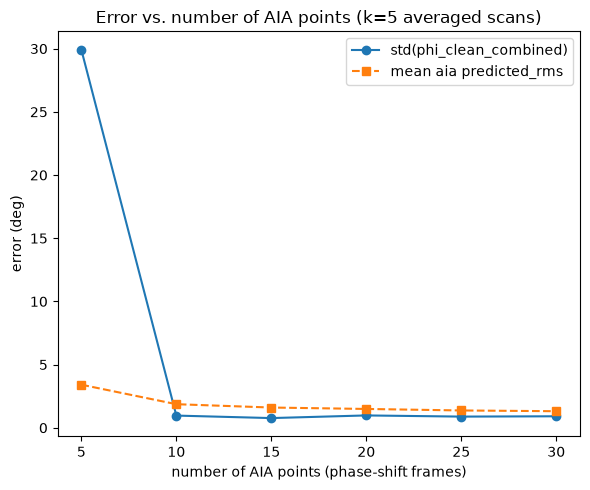

In [62]:
# Test B: error vs. number of AIA points (frames), fixed k = K_FIXED averages.
# Load the raw stacks for the first K_FIXED sample/ref files once, then rerun
# aia on a growing frame-count slice each iteration. Error metric is
# std(phi_clean_combined), same as Test A -- subtract_reference + remove_carrier
# on the K_FIXED-averaged sample/ref maps, for each n_points.
K_FIXED = 5  # number of repeat scans to average -- edit to taste

def load_stack(fname):
    d = np.load(DATA_DIR + fname)
    return d['images'][:, delta_crop:3000-delta_crop, delta_crop:4096-delta_crop, 0]

sample_stacks_full = [load_stack(f) for f in sample_files[:K_FIXED]]
ref_stacks_full = [load_stack(f) for f in ref_files[:K_FIXED]]
n_frames_total = sample_stacks_full[0].shape[0]
print(f"Frames available per stack: {n_frames_total}, K_FIXED={K_FIXED}")

n_points_list = list(range(5, n_frames_total + 1, 5))
errors_vs_npoints = []
predicted_rms_vs_npoints = []

for n_points in n_points_list:
    sample_res = [aia(s[:n_points], gain="auto") for s in sample_stacks_full]
    ref_res = [aia(s[:n_points], gain="auto") for s in ref_stacks_full]

    sample_c = combine_acquisitions([r.phi for r in sample_res], [r.b for r in sample_res])
    ref_c = combine_acquisitions([r.phi for r in ref_res], [r.b for r in ref_res])

    diff_c = subtract_reference(sample_c.phi, ref_c.phi, sample_c.mean_resultant)
    carrier_c = remove_carrier(diff_c.phi, sample_c.mean_resultant,
                                defocus=True, refine_iters=10, n_blocks=10)
    phi_clean_c = carrier_c.phi

    err_deg = np.degrees(np.std(phi_clean_c[400:600, 500:700]))
    rms_deg = np.degrees(np.mean([r.predicted_rms for r in sample_res + ref_res]))

    errors_vs_npoints.append(err_deg)
    predicted_rms_vs_npoints.append(rms_deg)
    print(f"n_points={n_points:2d}: std(phi_clean_combined)={err_deg:.3f} deg, "
          f"mean predicted_rms={rms_deg:.3f} deg")

plt.figure(figsize=(6, 5))
plt.plot(n_points_list, errors_vs_npoints, 'o-', label="std(phi_clean_combined)")
plt.plot(n_points_list, predicted_rms_vs_npoints, 's--', label="mean aia predicted_rms")
plt.xlabel("number of AIA points (phase-shift frames)")
plt.ylabel("error (deg)")
plt.title(f"Error vs. number of AIA points (k={K_FIXED} averaged scans)")
plt.legend()
plt.tight_layout()

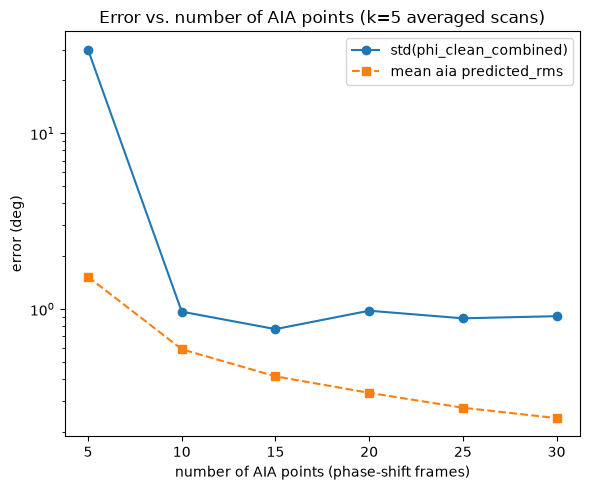

In [65]:
plt.figure(figsize=(6, 5))
plt.plot(n_points_list, errors_vs_npoints, 'o-', label="std(phi_clean_combined)")
plt.plot(n_points_list, predicted_rms_vs_npoints/np.sqrt([5, 10, 15, 20, 25, 30]), 's--', label="mean aia predicted_rms")
plt.xlabel("number of AIA points (phase-shift frames)")
plt.ylabel("error (deg)")
plt.title(f"Error vs. number of AIA points (k={K_FIXED} averaged scans)")
plt.legend()
plt.yscale('log')
plt.tight_layout()

5.035688552319588
0.910545541750735


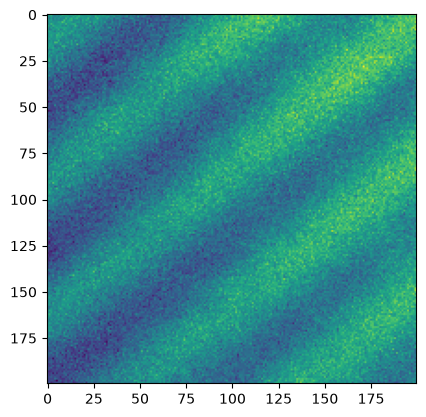

In [59]:
im = phi_clean_c[400:600, 500:700]
plt.imshow(im)
print(np.degrees(im.mean()))
print(np.degrees(im.std()))

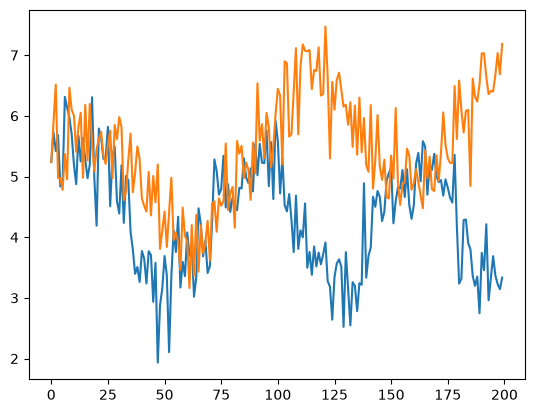

In [60]:
plt.plot(np.degrees(im[:,0]))
plt.plot(np.degrees(im[0,:]))